<a href="https://www.kaggle.com/code/sonawanelalitsunil/teen-mental-health-chatbot-ml-67?scriptVersionId=250388520" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/teen-mental-health-chatbot-dataset/final_teen_mental_health_chatbot_dataset (1).csv


##  Title:
Teen Mental Health Chatbot Dataset

##  Description:
The Teen Mental Health Chatbot Dataset is designed to support the development of conversational AI tools aimed at promoting emotional well-being among teenagers. It contains chat logs between users (primarily teens) and a mental health support chatbot. The dataset includes anonymized text exchanges that cover topics such as anxiety, depression, peer pressure, academic stress, self-esteem, relationships, and coping strategies.

Each conversation is labeled with relevant metadata such as emotional tone, intent, user sentiment, and chatbot response quality. This makes the dataset valuable for training and evaluating natural language processing (NLP) models for empathy detection, mental health classification, intent recognition, and personalized response generation.

Researchers, developers, and mental health professionals can use this dataset to build supportive AI companions, identify mental health patterns in teens, or analyze the impact of chatbot interactions on emotional states. Ethical use and privacy are emphasized, with all personally identifiable information removed.

## Import dataset

In [2]:
df = pd.read_csv('/kaggle/input/teen-mental-health-chatbot-dataset/final_teen_mental_health_chatbot_dataset (1).csv')

In [3]:
df.head()

,user_input,bot_response
0,I feel really sad today,I'm so sorry to hear that. Can you share what’...
1,I’m stressed about exams,That sounds overwhelming. Let’s talk about wha...
2,I feel anxious,I hear you. It’s okay to feel anxious sometime...
3,My friends don’t talk to me anymore,That must hurt. I'm here for you. Want to talk...
4,I’m so tired of everything,I'm really sorry you're feeling this way. You'...


In [4]:
df.tail()

,user_input,bot_response
282,I had fun in art class,Art’s fire! What’d you make?
283,I’m feeling good today,That’s awesome! What’s the vibe?
284,My friend sent a funny meme,Memes are life! What was it about?
285,I’m excited for the show,Shows are fire! What’s it about?
286,I got a cool notebook,Notebooks are sweet! What’s it for?


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_input    287 non-null    object
 1   bot_response  287 non-null    object
dtypes: object(2)
memory usage: 4.6+ KB


In [6]:
df.describe()

,user_input,bot_response
count,287,287
unique,278,287
top,I’m excited for the trip,I'm so sorry to hear that. Can you share what’...
freq,2,1


In [7]:
df.dtypes

user_input      object
bot_response    object
dtype: object

In [8]:
df.shape

(287, 2)

In [9]:
df.isnull().sum()

user_input      0
bot_response    0
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df.columns

Index(['user_input', 'bot_response'], dtype='object')

## Data visualizations

In [12]:
from wordcloud import WordCloud
from textblob import TextBlob
from collections import Counter
import nltk
from nltk.corpus import stopwords
from nltk.util import ngrams
import re

In [13]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)  # Remove URLs
    text = re.sub(r'\@w+|\#','', text)  # Remove mentions and hashtags
    text = re.sub(r'[^A-Za-z\s]', '', text)  # Keep letters and whitespace
    return text.lower()

df['user_input_clean'] = df['user_input'].astype(str).apply(clean_text)
df['bot_response_clean'] = df['bot_response'].astype(str).apply(clean_text)

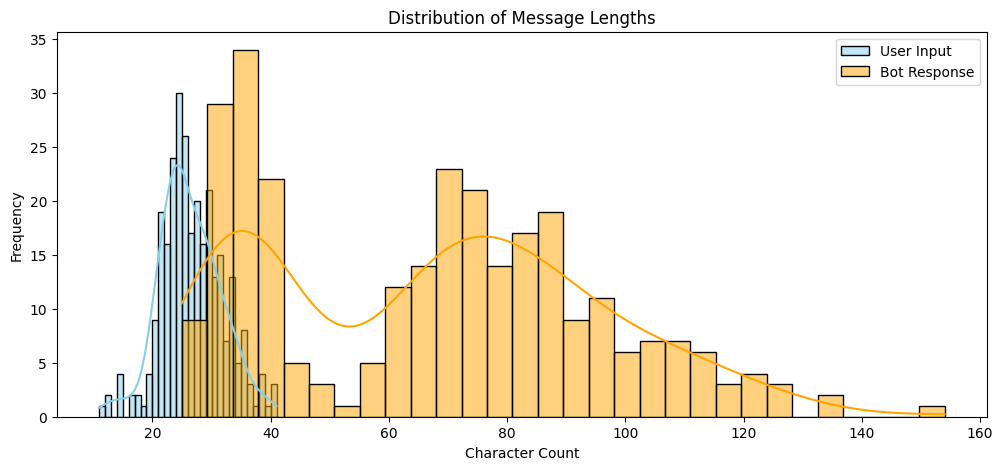

In [15]:
df['user_input_len'] = df['user_input'].str.len()
df['bot_response_len'] = df['bot_response'].str.len()

plt.figure(figsize=(12, 5))
sns.histplot(df['user_input_len'], bins=30, color='skyblue', label='User Input', kde=True)
sns.histplot(df['bot_response_len'], bins=30, color='orange', label='Bot Response', kde=True)
plt.title('Distribution of Message Lengths')
plt.xlabel('Character Count')
plt.ylabel('Frequency')
plt.legend()
plt.show()


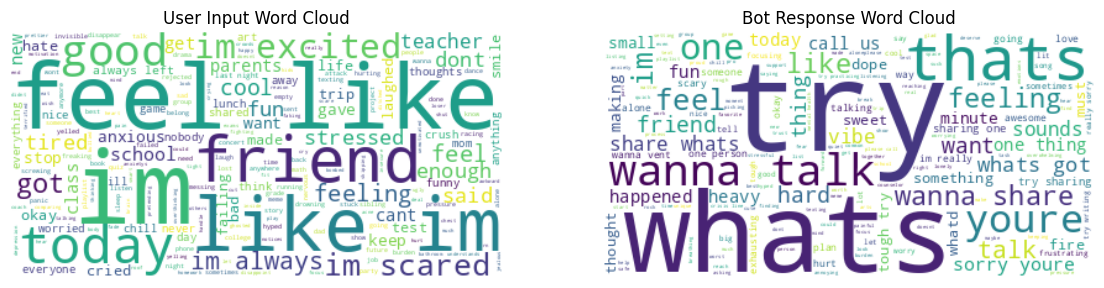

In [16]:
# Combine all text
user_text = ' '.join(df['user_input_clean'])
bot_text = ' '.join(df['bot_response_clean'])

stop_words = set(stopwords.words('english'))

wordcloud_user = WordCloud(stopwords=stop_words, background_color='white').generate(user_text)
wordcloud_bot = WordCloud(stopwords=stop_words, background_color='white').generate(bot_text)

# Plot
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(wordcloud_user, interpolation='bilinear')
plt.title('User Input Word Cloud')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_bot, interpolation='bilinear')
plt.title('Bot Response Word Cloud')
plt.axis('off')

plt.show()


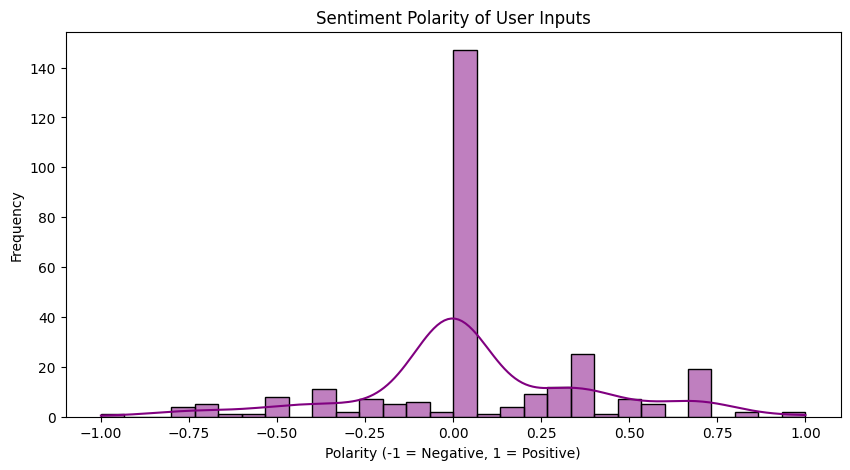

In [17]:
df['user_sentiment'] = df['user_input'].astype(str).apply(lambda x: TextBlob(x).sentiment.polarity)

plt.figure(figsize=(10, 5))
sns.histplot(df['user_sentiment'], bins=30, color='purple', kde=True)
plt.title('Sentiment Polarity of User Inputs')
plt.xlabel('Polarity (-1 = Negative, 1 = Positive)')
plt.ylabel('Frequency')
plt.show()


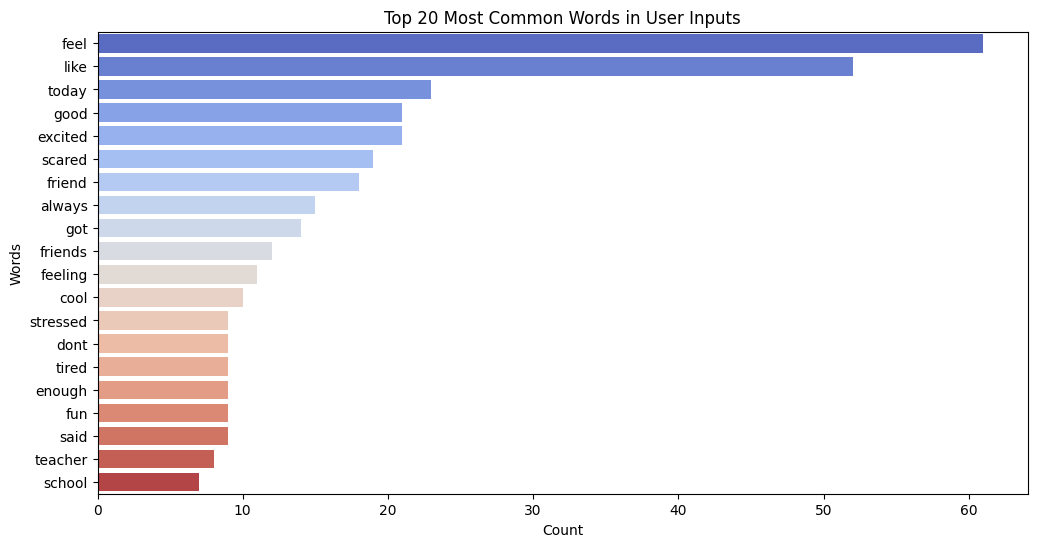

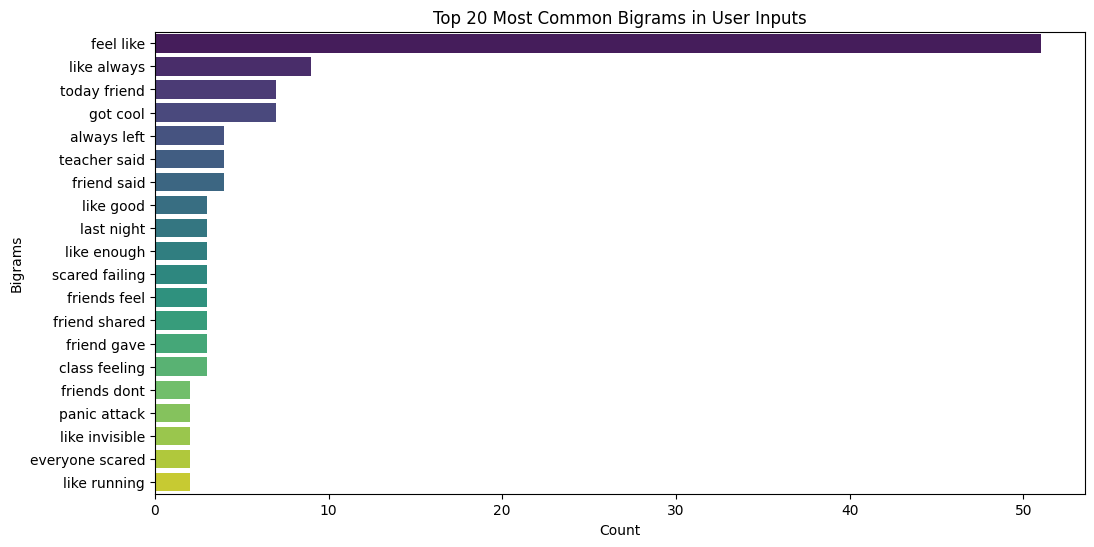

In [18]:
def get_common_words(text, n=20):
    words = nltk.word_tokenize(text)
    words = [word for word in words if word not in stop_words and len(word) > 2]
    return Counter(words).most_common(n)

def get_common_bigrams(text, n=20):
    tokens = nltk.word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]
    bigrams = ngrams(tokens, 2)
    return Counter(bigrams).most_common(n)

# Plotting
common_words = get_common_words(user_text)
words, counts = zip(*common_words)

plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=list(words), palette='coolwarm')
plt.title('Top 20 Most Common Words in User Inputs')
plt.xlabel('Count')
plt.ylabel('Words')
plt.show()

# Bigrams
common_bigrams = get_common_bigrams(user_text)
bigrams, counts = zip(*common_bigrams)
bigrams = [' '.join(b) for b in bigrams]

plt.figure(figsize=(12, 6))
sns.barplot(x=list(counts), y=bigrams, palette='viridis')
plt.title('Top 20 Most Common Bigrams in User Inputs')
plt.xlabel('Count')
plt.ylabel('Bigrams')
plt.show()


## Predictive modeling

In [19]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

In [20]:
import nltk
import re

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
# Clean the text (optional, improves performance)
import re
def clean_text(text):
    text = re.sub(r"http\S+|www\S+|https\S+", '', str(text))
    text = re.sub(r'\@w+|\#','', text)
    text = re.sub(r'[^A-Za-z\s]', '', text)
    return text.lower()

df['user_input'] = df['user_input'].astype(str).apply(clean_text)
df['bot_response'] = df['bot_response'].astype(str).apply(clean_text)

# Compute response length
df['bot_response_length'] = df['bot_response'].str.len()

# Create a binary target: 1 if bot response is longer than the median, else 0
median_length = df['bot_response_length'].median()
df['long_response'] = df['bot_response_length'].apply(lambda x: 1 if x > median_length else 0)

# Prepare features and target variable
X = df['user_input']
y = df['long_response']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# Train logistic regression model
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_tfidf, y_train)

# Predict on test set
y_pred = clf.predict(X_test_tfidf)

# Evaluate model
accuracy = accuracy_score(y_test, y_pred)
print(f'✅ Prediction Accuracy: {accuracy:.2f}')


✅ Prediction Accuracy: 0.67


## Thank you ...pls upvote!!!